# SMS Spam Detection with TensorFlow

SMS spam detection is a classic binary classification problem in machine learning. The goal is to automatically distinguish legitimate messages (ham) from unwanted messages (spam). This project leverages advanced natural language processing (NLP) and deep learning techniques to build several high-performance models.

**Project objectives:**
- Clean and prepare an SMS dataset
- Vectorize text data for deep learning models
- Build and compare several neural network architectures (dense embedding, Bi-LSTM, transfer learning with Universal Sentence Encoder)
- Evaluate performance using standard metrics (accuracy, precision, recall, F1-score)
- Visualize results to interpret model performance

This notebook is structured step by step to illustrate the scientific and technical approach from start to finish.

## 1. Importing Libraries

In this section, we import the essential libraries for data processing, visualization, text manipulation, and deep learning model building.

- **numpy, pandas**: efficient handling of numerical and tabular data
- **matplotlib, seaborn**: graphical visualization
- **scikit-learn**: preprocessing and evaluation tools
- **tensorflow, tensorflow_hub**: neural network creation and training, access to pre-trained models

Centralized imports ensure code clarity and reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

2026-04-21 21:04:18.830365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776805459.100132      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776805459.182094      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776805459.796691      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776805459.796747      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776805459.796750      16 computation_placer.cc:177] computation placer alr

## 2. Loading and Previewing the Dataset

We load the SMS dataset, which typically consists of two columns:
- **label**: indicates whether the message is "ham" (legitimate) or "spam"
- **Text**: the content of the SMS

An initial preview helps verify the structure, size, and quality of the data before any preprocessing.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nelsonvikou/sms-spam/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Data Cleaning and Label Encoding

Data cleaning is a crucial step to ensure the quality of learning:
- Remove unnecessary or redundant columns
- Rename columns for clarity
- Encode textual labels into numeric values (0 for ham, 1 for spam)

This preprocessing yields a dataset suitable for machine learning models.

In [3]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 4. Data Splitting and Conversion to NumPy Arrays

To assess the generalization ability of the models, we split the dataset into two parts:
- **Training set**: to fit the model parameters
- **Test set**: to evaluate performance on unseen data

Conversion to NumPy arrays ensures optimal compatibility with TensorFlow.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_enc'],
    test_size=0.2,
    random_state=42
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

## 5. Text Statistics for Vectorization

Before vectorizing the texts, it is useful to analyze:
- The average message length (in words)
- The total vocabulary (number of unique words)

These statistics guide the choice of vectorization parameters (padding, vocabulary size) and influence model performance.

In [5]:
avg_words_len = round(sum([len(i.split())
                      for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


## 6. Utility Functions for Training and Evaluation

To avoid redundancy and ensure consistency, we define functions that:
- Compile and train models with the same parameters
- Compute evaluation metrics (accuracy, precision, recall, F1-score)

This allows for objective comparison of different architectures.

In [6]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

## 7. Creating the Text Vectorization Layer

The `TextVectorization` layer transforms raw text into sequences of integers, each representing a word in the vocabulary. This step is essential to make textual data compatible with neural networks.

- Limits vocabulary size to avoid overfitting
- Standardizes text (lowercase, removes punctuation)
- Applies padding to standardize sequence length

Vectorization is adapted on the training set to ensure model robustness.

In [7]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

2026-04-21 21:04:49.485895: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 8. Model 1: Dense Embedding

This first model applies a dense embedding layer followed by global pooling and a dense layer:
- The embedding learns a dense vector representation for each word
- Global pooling summarizes the sequence into a single vector
- The final dense layer performs binary classification

This type of model is simple but effective for text classification tasks.

In [8]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8407 - loss: 0.4303 - val_accuracy: 0.9632 - val_loss: 0.1462
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9780 - loss: 0.1091 - val_accuracy: 0.9767 - val_loss: 0.0776
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9905 - loss: 0.0406 - val_accuracy: 0.9794 - val_loss: 0.0668
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9941 - loss: 0.0299 - val_accuracy: 0.9776 - val_loss: 0.0651
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9969 - loss: 0.0172 - val_accuracy: 0.9785 - val_loss: 0.0634


## 9. Model 2: Bi-LSTM (Bidirectional Long Short-Term Memory)

The Bi-LSTM model leverages the ability of recurrent networks to capture contextual dependencies in sequences:
- LSTMs process sequences in both directions (forward and backward)
- Allows for better understanding of the global context of the message
- Suitable for tasks where word order is important

This model is more powerful for natural language understanding than classic dense architectures.

In [9]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9008 - loss: 0.2828 - val_accuracy: 0.9794 - val_loss: 0.0776
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9894 - loss: 0.0394 - val_accuracy: 0.9830 - val_loss: 0.0620
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9977 - loss: 0.0112 - val_accuracy: 0.9785 - val_loss: 0.0843
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9987 - loss: 0.0051 - val_accuracy: 0.9767 - val_loss: 0.0948
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9996 - loss: 0.0034 - val_accuracy: 0.9794 - val_loss: 0.1061


## 10. Model 3: Transfer Learning with Universal Sentence Encoder (USE)

The Universal Sentence Encoder (USE) is a model pre-trained on large amounts of text to generate vector representations of sentences:
- Leverages advanced linguistic knowledge without training a complex model from scratch
- The produced embeddings are suitable for many NLP tasks
- Transfer learning improves performance on moderately sized datasets

This model demonstrates the power of modern NLP approaches.

In [10]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8316 - loss: 0.4763 - val_accuracy: 0.9713 - val_loss: 0.1203
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9748 - loss: 0.0960 - val_accuracy: 0.9776 - val_loss: 0.0720
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9846 - loss: 0.0557 - val_accuracy: 0.9812 - val_loss: 0.0604
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9830 - val_loss: 0.0556
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9886 - loss: 0.0439 - val_accuracy: 0.9848 - val_loss: 0.0532


## 11. Model Evaluation and Comparison

After training, each model is evaluated on the test set using several metrics:
- **Accuracy**: proportion of correct predictions
- **Precision**: proportion of true positives among positive predictions
- **Recall**: proportion of true positives among actual positives
- **F1-score**: harmonic mean of precision and recall

Objective comparison helps identify the most suitable model for SMS spam detection.

In [11]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.978475   0.943262  0.892617  0.917241
Bi-LSTM                  0.979372   0.931507  0.912752  0.922034
Transfer Learning (USE)  0.984753   0.958333  0.926174  0.941980


## 12. Performance Visualization

Results are summarized in graphical form for easier interpretation:
- Bar charts to compare model scores
- Learning curves to visualize convergence

Visualization helps to better understand the strengths and weaknesses of each approach.

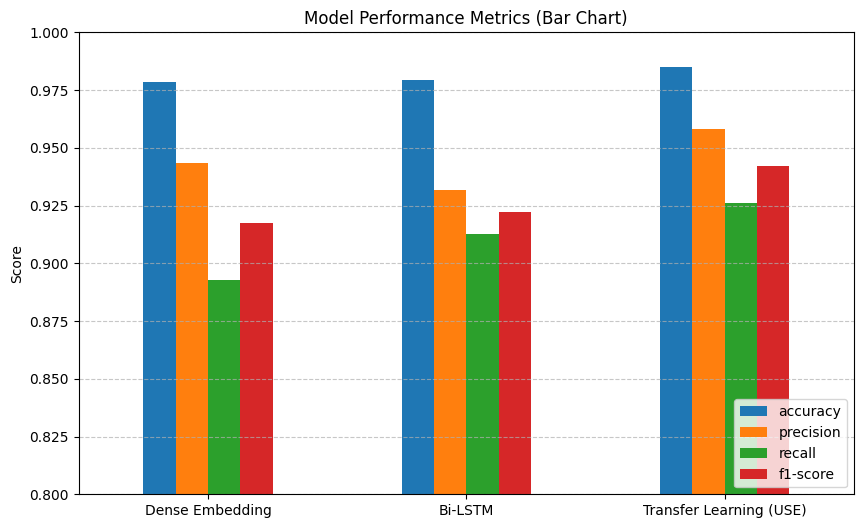

In [12]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

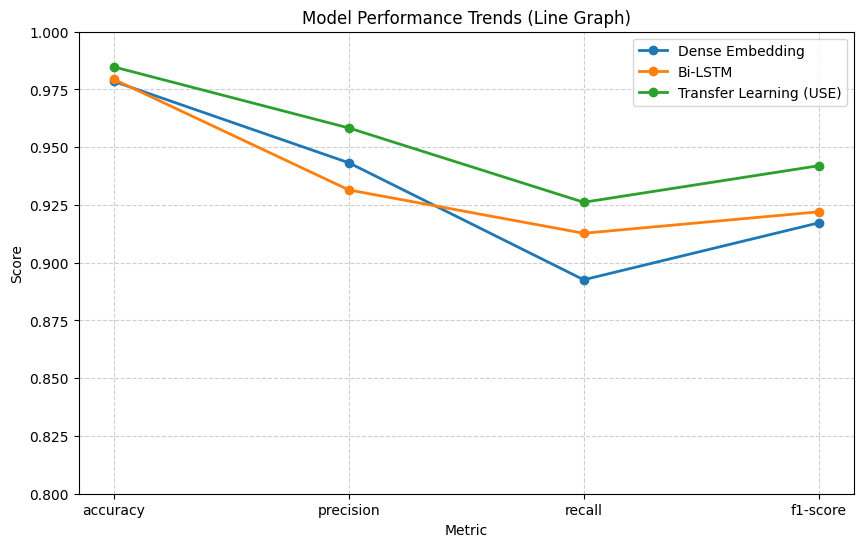

In [13]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Conclusion

This notebook explored different text classification approaches for SMS spam detection, combining theory and practice:
- Preprocessing and vectorization of textual data
- Construction of various deep learning models
- Use of transfer learning
- Rigorous evaluation and visualization of results

The presented methodology is generalizable to other NLP tasks and illustrates the complementarity between theory and experimentation.